In [8]:
1626**2 + 47**2

2646085

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# file_name = "iladata.csv"
file_name = "iladata.csv"
df = pd.read_csv(file_name)

print(df.columns.to_list())
# ['Sample in Buffer', 'Sample in Window', 'TRIGGER', 'rx_data_valid', 'rx_data_I[11:0]', 'user_probe_0[4:0]', 'rx_data_Q[11:0]', 'user_probe_1[4:0]', 'valid', 'bit_out[2:0]', 'phase_out[10:0]', 'tx_data_I[11:0]', 'tx_data_Q[11:0]', 'delta_out[2:0]', 'out_i[11:0]', 'out_q[11:0]', 'bit_in[2:0]', 'bit_in_d1[2:0]', 'data_in_int[13:0]']

df = df.drop(index=0).loc[:, ["rx_data_valid", "rx_data_I[11:0]", "rx_data_Q[11:0]", "out_i[11:0]", "out_q[11:0]", "valid"]].astype(int)
df = df.where(df["rx_data_valid"] == 1).dropna().reset_index(drop=True).drop(columns=["rx_data_valid"]).astype(int)
df.head()

x = np.arange(len(df))
# plt.figure(figsize=(18, 4))
# plt.step(x, df["rx_data_I[11:0]"], label="rx_data_I[11:0]")
# plt.step(x, df["rx_data_Q[11:0]"], label="rx_data_Q[11:0]")
# plt.xlim(0, 200)
# plt.legend()
# plt.show()

# plt.figure(figsize=(18, 4))
# plt.step(x, df["out_i[11:0]"], label="out_i[11:0]")
# plt.step(x, df["out_q[11:0]"], label="out_q[11:0]")
# plt.xlim(0, 200)
# plt.legend()
# plt.show()


# 补码
def get_twos_complement(array, bits):
    return np.where(array >= 0, array, (1 << bits) + array)


sample_width = 12

real = get_twos_complement(df["rx_data_I[11:0]"], sample_width)
imag = get_twos_complement(df["rx_data_Q[11:0]"], sample_width)

np.savetxt("./tb/tx_signal.hex", real * 2**sample_width + imag, fmt="%X")

real = df["rx_data_I[11:0]"]
imag = df["rx_data_Q[11:0]"]

def plot_star(signal, title="Star Diagram"):
    # return
    fig, ax = plt.subplots(figsize=(4, 4), dpi=120)
    ax.plot(np.real(signal), np.imag(signal), ".", markersize=2)

    max_val = np.max(np.abs(signal)) * 1.1
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.set_title(title)

    ax.set_aspect("equal", adjustable="box")  # ✅ 坐标轴固定1:1

    fig.tight_layout()

    # 加上判决门限theta = 0 pi/4 pi/2 ...

    M = 8
    for m in range(M):
        theta = 2 * np.pi * m / M
        x = np.array([-max_val, max_val])
        y = np.tan(theta) * x
        ax.plot(x, y, 'r--', linewidth=0.8)

    plt.show()


plot_star(real + 1j * imag, "Original Signal")
real2 = df["out_i[11:0]"]
imag2 = df["out_q[11:0]"]
plot_star(real2 + 1j * imag2, "Recovered Signal")

# 选取valid为1的点
df_valid = df.where(df["valid"] == 1).dropna().reset_index(drop=True)
real3 = df_valid["out_i[11:0]"]
imag3 = df_valid["out_q[11:0]"]
if len(real3) != 0:
    plot_star(real3 + 1j * imag3, "Recovered Signal with valid = 1")

# 计算df['rx_data_I[11:0]']频谱
plt.plot(np.log10(np.abs(np.fft.rfft(real + 1j*imag))))
plt.show()

PermissionError: [Errno 13] Permission denied: 'd:\\Downloads\\iladata.csv'

In [ ]:
# error rate
delta_out = df.where(df["valid"] == 1)["delta_out[2:0]"].dropna().astype(int).to_list()
error_count = 0
last = 7
for i in range(len(delta_out)):
    new = delta_out[i]
    # print((new - last) % 8)
    if (new - last) % 8 != 1:
        error_count += 1
    last = new

print(f"Total: {len(delta_out)}, Error: {error_count}, Error Rate: {error_count / len(delta_out):.2%}")

Total: 1365, Error: 3, Error Rate: 0.22%


In [99]:
from vcdvcd import VCDVCD
import pandas as pd

# === 参数 ===
vcd_path = "demod_wave.vcd"         # VCD 文件路径
clk_name = "Demod_tb.clk"          # 时钟信号的完整层级名（根据你的VCD内容修改）
# output_csv = "wave.csv"

# === 解析 VCD ===
vcd = VCDVCD(vcd_path, only_sigs=False, store_tvs=True)
signals = list(vcd.references_to_ids.keys())
print(f"检测到信号: {signals}")

clk_tv = vcd[clk_name].tv  # [(time, value), ...]
clk_edges = []
last_val = None

# === 提取时钟上升沿时间点 ===
for t, val in clk_tv:
    if last_val == '0' and val == '1':
        clk_edges.append(t)
    last_val = val

print(f"检测到 {len(clk_edges)} 个时钟上升沿")

# === 对每个信号建立时间序列 ===
signal_values = {}
for sig in signals:
    tv = vcd[sig].tv
    # 将tv中的二进制字符串转换为整数
    tv = [(t, int(val, 2)) for t, val in tv if val is not None]
    idx = 0
    curr_val = tv[0][1]
    values = []
    for edge in clk_edges:
        # 移动到当前时刻的最后一个值
        while idx + 1 < len(tv) and tv[idx + 1][0] <= edge:
            idx += 1
            curr_val = tv[idx][1]
        values.append(curr_val)
    signal_values[sig] = values

# === 输出为 CSV ===
df = pd.DataFrame(signal_values, index=range(len(clk_edges)))
# df.to_csv(output_csv, index_label='Cycle')
# print(f"已保存到 {output_csv}")

# df.set_index(pd.Index(clk_edges, name='Cycle'), inplace=True)


检测到信号: ['Demod_tb.valid', 'Demod_tb.phase_out[10:0]', 'Demod_tb.frame_start', 'Demod_tb.frame_end', 'Demod_tb.bit_out[2:0]', 'Demod_tb.DATA_W', 'Demod_tb.N', 'Demod_tb.clk', 'Demod_tb.in_i[11:0]', 'Demod_tb.in_q[11:0]', 'Demod_tb.rst_n', 'Demod_tb.i[31:0]', 'Demod_tb.u_Demod.clk', 'Demod_tb.u_Demod.frame_end', 'Demod_tb.u_Demod.frame_start', 'Demod_tb.u_Demod.in_i[11:0]', 'Demod_tb.u_Demod.in_i_interpolated[15:0]', 'Demod_tb.u_Demod.in_q[11:0]', 'Demod_tb.u_Demod.in_q_interpolated[15:0]', 'Demod_tb.u_Demod.rst_n', 'Demod_tb.u_Demod.valid', 'Demod_tb.u_Demod.valid_out', 'Demod_tb.u_Demod.valid_in', 'Demod_tb.u_Demod.sync_time_out', 'Demod_tb.u_Demod.signal_valid', 'Demod_tb.u_Demod.phase_out[10:0]', 'Demod_tb.u_Demod.phase_high[2:0]', 'Demod_tb.u_Demod.phase[10:0]', 'Demod_tb.u_Demod.out_q[11:0]', 'Demod_tb.u_Demod.out_i[11:0]', 'Demod_tb.u_Demod.in_q_output_tvalid', 'Demod_tb.u_Demod.in_q_input_tready', 'Demod_tb.u_Demod.in_i_output_tvalid', 'Demod_tb.u_Demod.in_i_input_tready', 'Demod

Selected signals: ['Demod_tb.phase_out', 'Demod_tb.valid', 'Demod_tb.u_Demod.out_i', 'Demod_tb.u_Demod.out_q', 'Demod_tb.in_i', 'Demod_tb.in_q']
匹配到信号: Demod_tb.phase_out[10:0]
匹配到信号: Demod_tb.valid
匹配到信号: Demod_tb.u_Demod.out_i[11:0]
匹配到信号: Demod_tb.u_Demod.out_q[11:0]
匹配到信号: Demod_tb.in_i[11:0]
匹配到信号: Demod_tb.in_q[11:0]


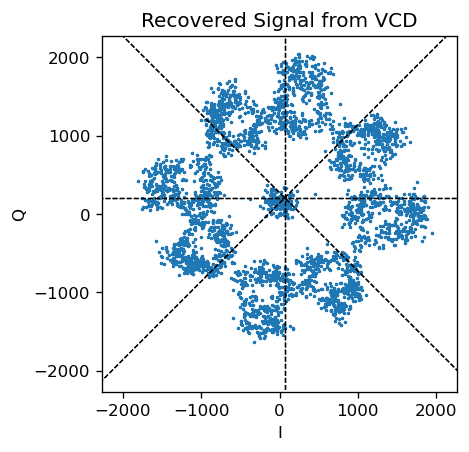

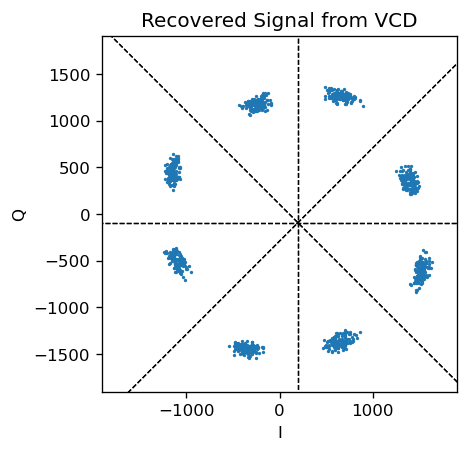

In [124]:
import re

signals = [
"""Demod_tb
phase_out""",
# """Demod_tb
# u_Demod
# valid_in""",
"""Demod_tb
valid""",
"""Demod_tb
u_Demod
out_i""",
"""Demod_tb
u_Demod
out_q""",

"""Demod_tb
in_i""",

"""Demod_tb
in_q""",

]

signals = [sig.replace("\n", ".") for sig in signals]
print("Selected signals:", signals)

# === 选择信号 ===
# 匹配时不考虑col结尾的位宽
selected_signals = pd.DataFrame()
for sig in signals:
    for col in df.columns:
        if sig in col:
            print(f"匹配到信号: {col}")
            selected_signals[col] = df[col]

signed_id = [0,2,3,4,5]

for idx, col in enumerate(selected_signals.columns):
    if idx in signed_id:
        if re.search(r'\[.*\]', col):
            # 提取位宽
            width = int(re.search(r'\[(\d+):0\]', col).group(1)) + 1
        else:
            width = 1

        # 计算补码
        selected_signals[col] = selected_signals[col].apply(lambda x: x - (1 << width) if x >= (1 << (width - 1)) else x)

    
import matplotlib.pyplot as plt
import numpy as np

# selected_signals.iloc[:,1] 前roll一位
# selected_signals.iloc[:,1] = selected_signals.iloc[:,1].shift(1)

# selected_signals = selected_signals.where(selected_signals.iloc[:,1] == 1).dropna().reset_index(drop=True)
# selected_signals.plot(subplots=True, figsize=(12, 2 * len(selected_signals.columns)), grid=True)

# 对selected_signals.iloc[:,0]绘制直方图
# plt.figure(figsize=(6, 4))
# plt.hist(selected_signals.iloc[:,0], bins=200)
# plt.title(f"Histogram of {selected_signals.columns[0]}")
# plt.xlabel(selected_signals.columns[0])
# plt.ylabel("Frequency")
# plt.grid(axis='y', alpha=0.75)
# plt.show()

def plot_star(signal, title="Star Diagram"):
    # return
    fig, ax = plt.subplots(figsize=(4, 4), dpi=120)
    ax.plot(np.real(signal), np.imag(signal), ".", markersize=2)

    max_val = np.max(np.abs(signal)) * 1.1
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.set_title(title)

    ax.set_aspect("equal", adjustable="box")  # ✅ 坐标轴固定1:1

    fig.tight_layout()

    # 加上判决门限theta = 0 pi/4 pi/2 ...

    M = 8
    # for m in range(M):
    #     theta = 2 * np.pi * m / M
    #     x = np.array([-max_val, max_val])
    #     y = np.tan(theta) * x
    #     ax.plot(x, y, '--', c = 'gray', linewidth=0.8, alpha=0.5)

    moved_center = (np.max(np.real(signal)) + np.min(np.real(signal))) / 2 + 1j * (np.max(np.imag(signal)) + np.min(np.imag(signal))) / 2

    # 画出平移后的线
    for m in range(M):
        theta = 2 * np.pi * m / M
        x = np.array([-max_val*2, max_val*2]) + np.real(moved_center)
        y = np.tan(theta) * (x - np.real(moved_center)) + np.imag(moved_center)
        ax.plot(x, y, '--', c = 'black', linewidth=0.8)

    plt.show()

start_point = 200

# plot_star((selected_signals.iloc[:,2] + 1j * selected_signals.iloc[:,3])[start_point*6:-4], "Recovered Signal from VCD")
plot_star((selected_signals.iloc[:,4] + 1j * selected_signals.iloc[:,5])[start_point*6:-4], "Recovered Signal from VCD")

selected_signals.iloc[:,1] = selected_signals.iloc[:,1].shift(1)

selected_signals = selected_signals.where(selected_signals.iloc[:,1] == 1).dropna().reset_index(drop=True)

plot_star((selected_signals.iloc[:,2] + 1j * selected_signals.iloc[:,3])[start_point:-4], "Recovered Signal from VCD")